In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import math

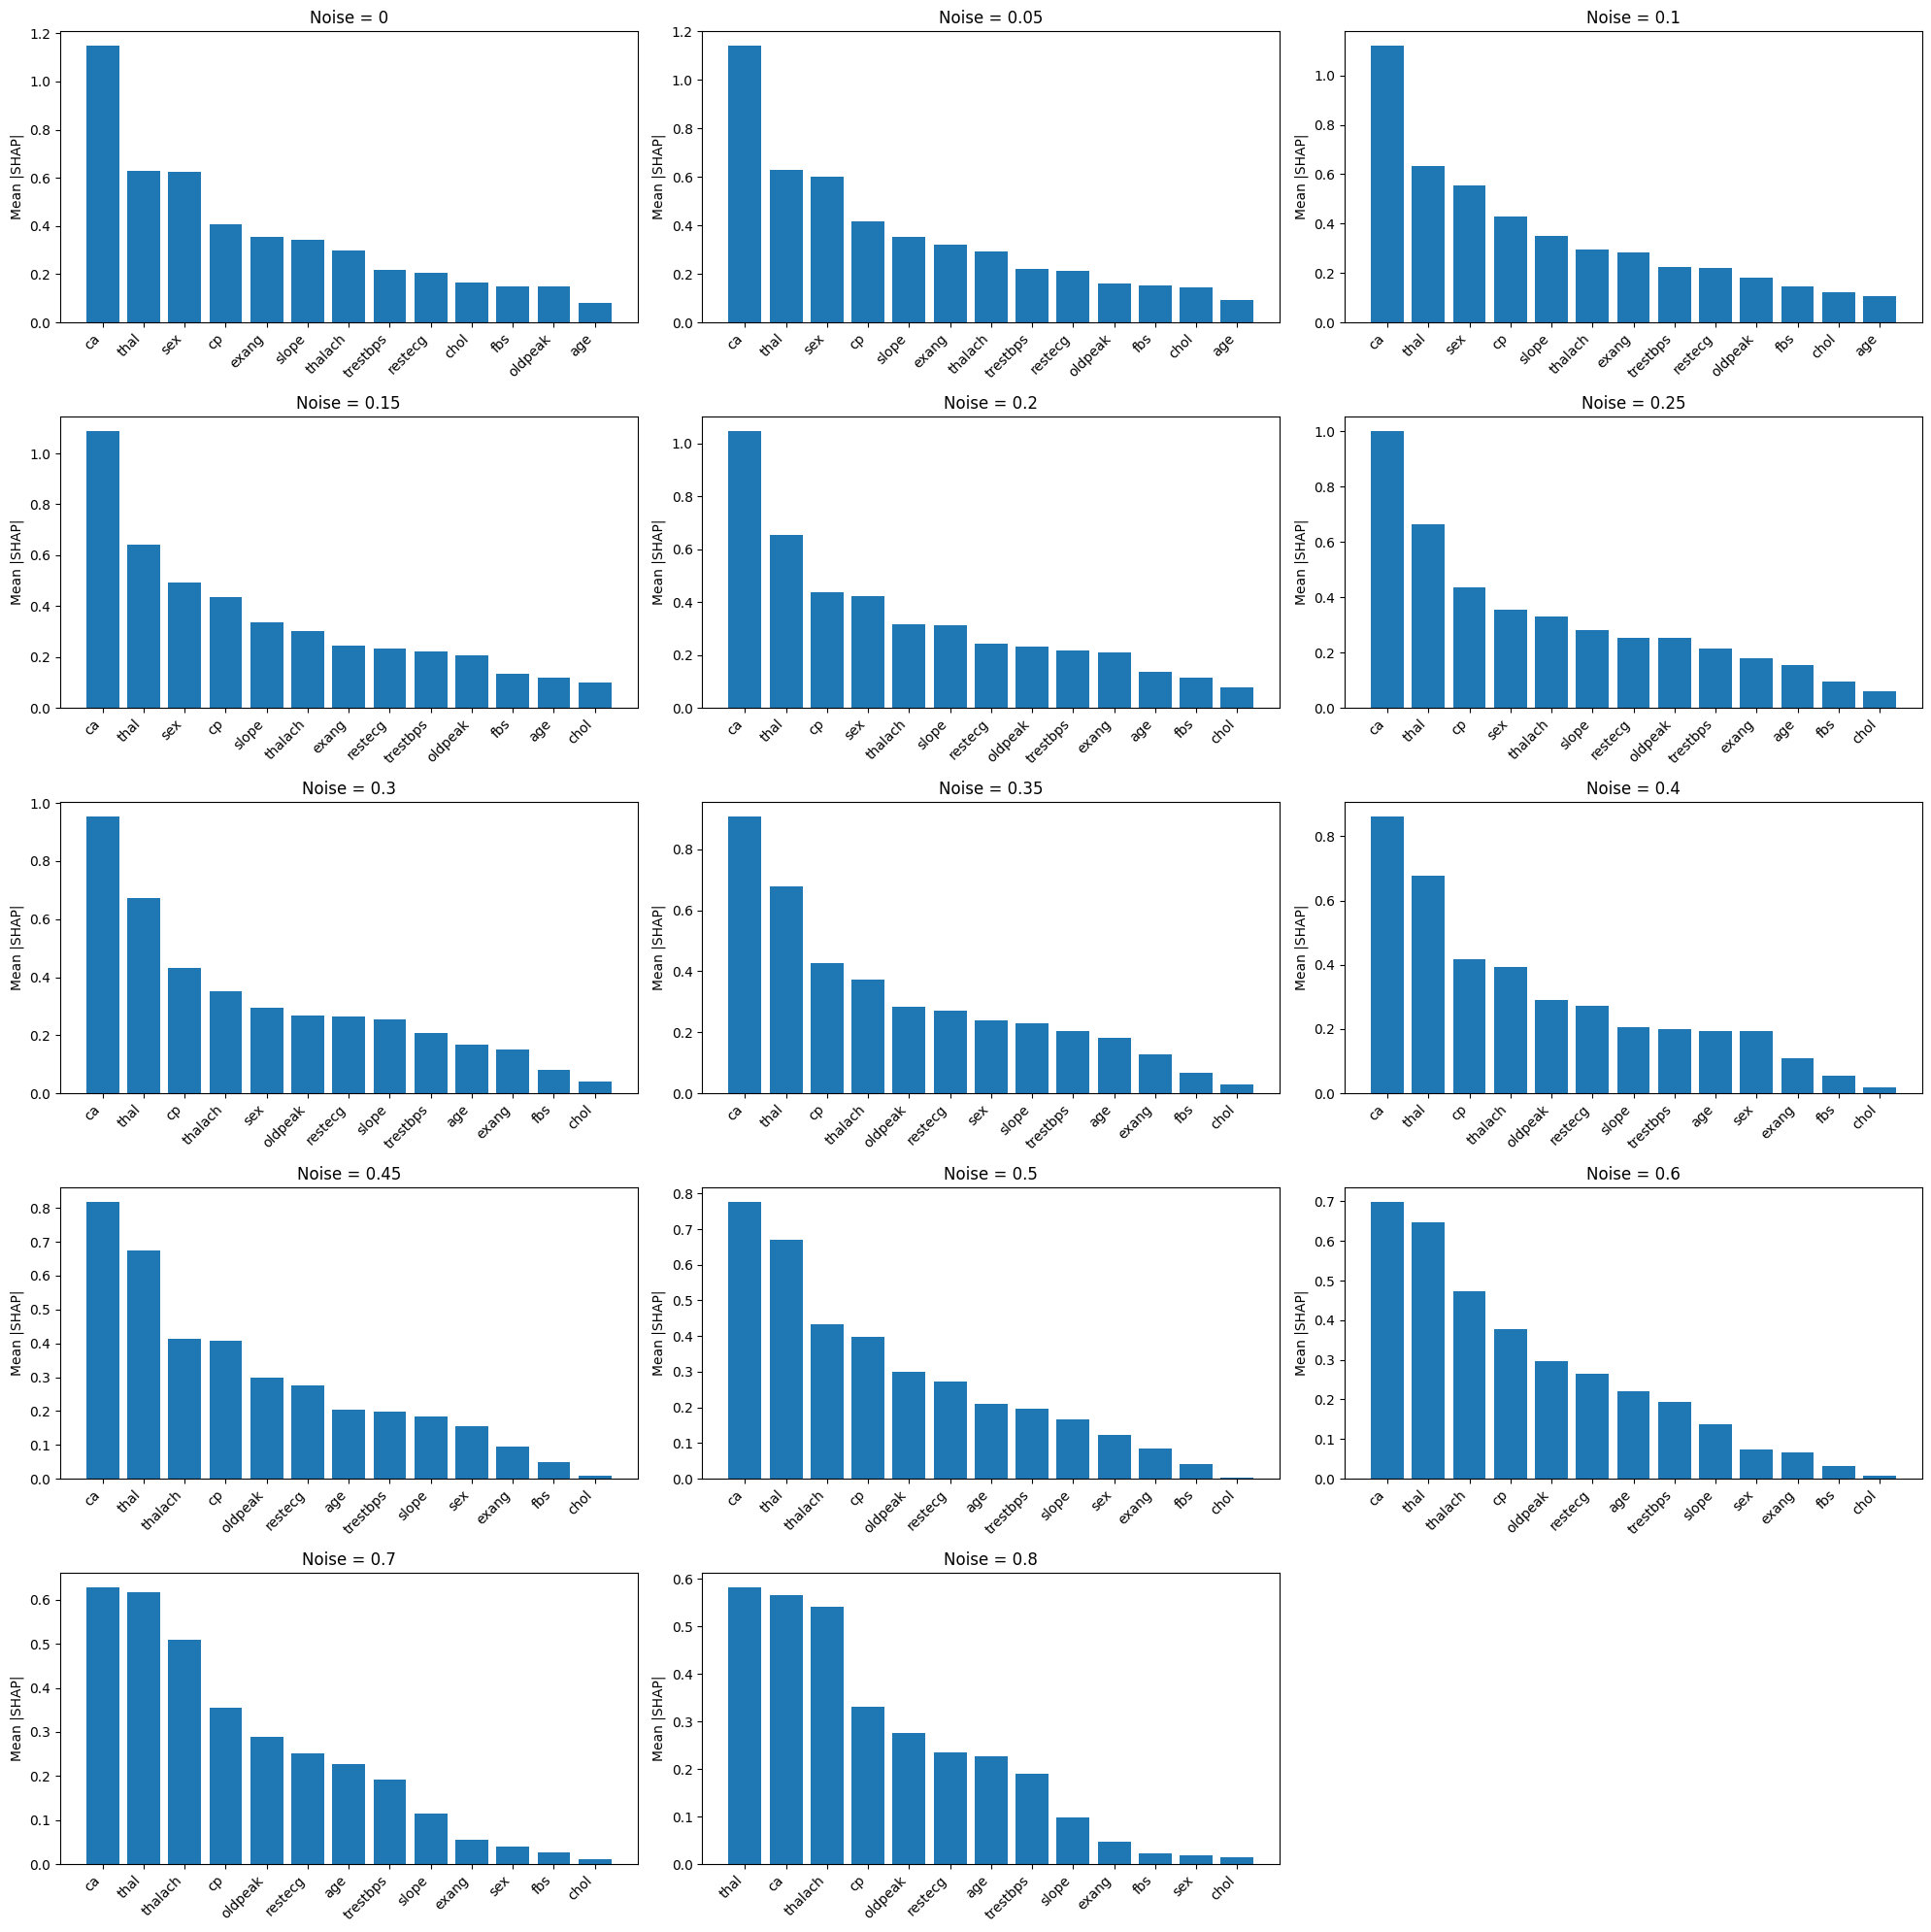

In [2]:
files = sorted(glob.glob("logisticRegression/results/lr_shap_noise_*.csv"))
files = sorted(files, key=lambda x: float(x.split("_")[-1].replace(".csv", "")))

n = len(files)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))

# Ensure axes is always 1D
axes = axes.flatten() if n > 1 else [axes]

for i, file in enumerate(files):
    ax = axes[i]
    
    noise_level = file.split("_")[-1].replace(".csv", "")
    df = pd.read_csv(file)
    
    df = df.sort_values(by="mean_abs_shap", ascending=False)
    
    ax.bar(range(len(df)), df["mean_abs_shap"])
    ax.set_title(f"Noise = {noise_level}")
    
    # Proper tick handling
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["feature"], rotation=45, ha='right')
    
    ax.set_ylabel("Mean |SHAP|")

# Remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()